In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import time

N_SEEDS = 5         
N_EPOCHS = 500      
BATCH_SIZE = 256
LATENT_DIM = 8
LR = 1e-3

In [45]:
df = pd.read_csv('features_v5.csv')
X = df.drop(columns='user')

In [46]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [47]:
X_scaled = X_scaled.clip(lower=-5, upper=5)

In [48]:
l = pd.read_csv('cert_dataset/insiders/insiders.csv')
INSIDERS = l[l['dataset'] == 6.2]['user'].tolist()
print(f"Insiders connus : {INSIDERS}")

Insiders connus : ['ACM2278', 'CMP2946', 'PLJ1771', 'CDE1846', 'MBG3183']


In [49]:
X_train = X_scaled[~df['user'].isin(INSIDERS)]
X_tensor_train = torch.FloatTensor(X_train.values.copy())
X_tensor_all = torch.FloatTensor(X_scaled.values.copy())

users = df['user'].astype(str).to_numpy()
n_features = X_scaled.shape[1] 

print(f"n_users = {len(df)}, n_features = {n_features}, n_train = {len(X_train)}")

n_users = 4000, n_features = 67, n_train = 3995


In [50]:
class Autoencoder(nn.Module):
    def __init__(self, n_features, latent_dim=LATENT_DIM):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 38),
            nn.BatchNorm1d(38),
            nn.ReLU(),
            nn.Linear(38, 26),
            nn.BatchNorm1d(26),
            nn.ReLU(),
            nn.Linear(26, 18),
            nn.BatchNorm1d(18),
            nn.ReLU(),
            nn.Linear(18, latent_dim))
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 18),
            nn.BatchNorm1d(18),
            nn.ReLU(),
            nn.Linear(18, 26),
            nn.BatchNorm1d(26),
            nn.ReLU(),
            nn.Linear(26, 38),
            nn.BatchNorm1d(38),
            nn.ReLU(),
            nn.Linear(38, n_features))
        
    def forward(self, x):
        return self.decoder(self.encoder(x))


class AutoencoderSkip(nn.Module):
    def __init__(self, n_features, latent_dim=LATENT_DIM):
        super().__init__()
        
        self.enc1 = nn.Sequential(nn.Linear(n_features, 38), nn.BatchNorm1d(38), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Linear(38, 26),          nn.BatchNorm1d(26), nn.ReLU())
        self.enc3 = nn.Sequential(nn.Linear(26, 18),          nn.BatchNorm1d(18), nn.ReLU())
        self.enc4 = nn.Linear(18, latent_dim)
        
        self.dec1 = nn.Sequential(nn.Linear(latent_dim, 18),  nn.BatchNorm1d(18), nn.ReLU())
        self.dec2 = nn.Sequential(nn.Linear(18 + 26, 26),     nn.BatchNorm1d(26), nn.ReLU())
        self.dec3 = nn.Sequential(nn.Linear(26 + 38, 38),     nn.BatchNorm1d(38), nn.ReLU())
        self.dec4 = nn.Linear(38, n_features)
        
    def forward(self, x):
        h1 = self.enc1(x)
        h2 = self.enc2(h1)
        h3 = self.enc3(h2)
        z = self.enc4(h3)
        
        d1 = self.dec1(z)
        d2 = self.dec2(torch.cat([d1, h2], dim=1))
        d3 = self.dec3(torch.cat([d2, h1], dim=1))
        x_hat = self.dec4(d3)
        
        return x_hat

In [51]:
class VAE(nn.Module):
    def __init__(self, n_features, latent_dim=LATENT_DIM):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 38), 
            nn.BatchNorm1d(38), 
            nn.ReLU(),
            nn.Linear(38, 26),         
            nn.BatchNorm1d(26), 
            nn.ReLU(),
            nn.Linear(26, 18),         
            nn.ReLU())
        
        self.fc_mu = nn.Linear(18, latent_dim)
        self.fc_logvar = nn.Linear(18, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 18), 
            nn.BatchNorm1d(18), 
            nn.ReLU(),
            nn.Linear(18, 26),         
            nn.BatchNorm1d(26), 
            nn.ReLU(),
            nn.Linear(26, 38),         
            nn.BatchNorm1d(38), 
            nn.ReLU(),
            nn.Linear(38, n_features))
        
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparametrize(self, mu, logvar):
        return mu + torch.exp(0.5*logvar) * torch.randn_like(mu)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decoder(z), mu, logvar


class VAESkip(nn.Module):
    def __init__(self, n_features, latent_dim=LATENT_DIM):
        super().__init__()
        
        self.enc1 = nn.Sequential(nn.Linear(n_features, 38), nn.BatchNorm1d(38), nn.ReLU())
        self.enc2 = nn.Sequential(nn.Linear(38, 26),          nn.BatchNorm1d(26), nn.ReLU())
        self.enc3 = nn.Sequential(nn.Linear(26, 18),          nn.BatchNorm1d(18), nn.ReLU())
        
        self.fc_mu = nn.Linear(18, latent_dim)
        self.fc_logvar = nn.Linear(18, latent_dim)
        
        self.dec1 = nn.Sequential(nn.Linear(latent_dim, 18),  nn.BatchNorm1d(18), nn.ReLU())
        self.dec2 = nn.Sequential(nn.Linear(18 + 26, 26),     nn.BatchNorm1d(26), nn.ReLU())
        self.dec3 = nn.Sequential(nn.Linear(26 + 38, 38),     nn.BatchNorm1d(38), nn.ReLU())
        self.dec4 = nn.Linear(38, n_features)
        
    def reparametrize(self, mu, logvar):
        return mu + torch.exp(0.5*logvar) * torch.randn_like(mu)
    
    def forward(self, x):
        h1 = self.enc1(x) 
        h2 = self.enc2(h1) 
        h3 = self.enc3(h2)
        
        mu = self.fc_mu(h3) 
        logvar = self.fc_logvar(h3)
        z = self.reparametrize(mu, logvar)
        
        d1 = self.dec1(z)
        d2 = self.dec2(torch.cat([d1, h2], dim=1))
        d3 = self.dec3(torch.cat([d2, h1], dim=1))
        return self.dec4(d3), mu, logvar

In [52]:
def vae_loss_fn(x, x_hat, mu, logvar, beta=0.01):
    """Loss du VAE avec beta faible : on privilégie la reconstruction."""
    recon = F.mse_loss(x_hat, x, reduction='mean')
    kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return recon + beta * kl


def train_ae(model, loader, n_epochs=N_EPOCHS, lr=LR, label="AE"):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
    best_loss  = float('inf')
    best_state = None
    
    for epoch in range(n_epochs):
        model.train()
        ep_loss = 0
        for (batch,) in loader:
            recon = model(batch)
            loss = F.mse_loss(recon, batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            ep_loss += loss.item()
            
        avg = ep_loss / len(loader)
        
        if avg < best_loss:
            best_loss = avg
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            
        if epoch % 20 == 0:
            print(f"[{label}] Epoch {epoch} — Loss: {avg:.4f}")    
            
    model.load_state_dict(best_state)
    return model, best_loss


def train_vae(model, loader, n_epochs=N_EPOCHS, lr=LR, label="VAE"):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    best_loss  = float('inf')
    best_state = None
    
    for epoch in range(n_epochs):
        model.train()
        ep_loss = 0
        beta = min(0.01, 0.01 * epoch / 100)  
        
        for (batch,) in loader:
            x_hat, mu, logvar = model(batch)
            loss = vae_loss_fn(batch, x_hat, mu, logvar, beta=beta)
            opt.zero_grad()
            loss.backward()
            opt.step()
            ep_loss += loss.item()
            
        avg = ep_loss / len(loader)
        
        if avg < best_loss:
            best_loss = avg
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            
        if epoch % 20 == 0:
            print(f"[{label}] Epoch {epoch} — Loss: {avg:.4f}")  
        
    model.load_state_dict(best_state)
    return model, best_loss

In [53]:
def errors_ae(model, X_all):
    """MSE par user pour un AE classique."""
    model.eval()
    with torch.no_grad():
        return torch.mean((X_all - model(X_all)) ** 2, dim=1).numpy()


def errors_vae(model, X_all, n_samples=10):
    """MSE moyenné sur n_samples reparamétrages : le VAE est stochastique."""
    model.eval()
    with torch.no_grad():
        errs = []
        for _ in range(n_samples):
            x_hat, _, _ = model(X_all)
            errs.append(torch.mean((X_all - x_hat) ** 2, dim=1).numpy())
        return np.mean(errs, axis=0)

In [54]:
def train_multi_seed(model_class, train_fn, errors_fn, name, n_seeds=N_SEEDS):
    """
    Entraîne le même modèle avec n_seeds initialisations différentes.
    Retourne un array (n_seeds, n_users) avec les erreurs de chaque run.
    """
    all_errors = []
    losses = []
    t0 = time.time()
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        np.random.seed(seed)
        # Nouveau loader avec generator pour le shuffle reproductible
        g = torch.Generator()
        g.manual_seed(seed)
        ds = TensorDataset(X_tensor_train)
        ld = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
        
        model = model_class(n_features)
        model, best_loss = train_fn(model, ld)
        errs = errors_fn(model, X_tensor_all)
        all_errors.append(errs)
        losses.append(best_loss)
    elapsed = time.time() - t0
    print(f"  {name:10s}: {n_seeds} seeds en {elapsed:.0f}s | best loss = {np.mean(losses):.4f} ± {np.std(losses):.4f}")
    return np.array(all_errors)

print(f"=== Multi-seed training ({N_SEEDS} seeds × {N_EPOCHS} epochs × 4 modèles) ===")
errs_ae    = train_multi_seed(Autoencoder,     train_ae,  errors_ae,  'AE')
errs_skip  = train_multi_seed(AutoencoderSkip, train_ae,  errors_ae,  'AESkip')
errs_vae   = train_multi_seed(VAE,             train_vae, errors_vae, 'VAE')
errs_vskip = train_multi_seed(VAESkip,         train_vae, errors_vae, 'VAESkip')

=== Multi-seed training (5 seeds × 500 epochs × 4 modèles) ===
[AE] Epoch 0 — Loss: 0.8398
[AE] Epoch 20 — Loss: 0.3073
[AE] Epoch 40 — Loss: 0.2555
[AE] Epoch 60 — Loss: 0.2302
[AE] Epoch 80 — Loss: 0.2136
[AE] Epoch 100 — Loss: 0.2061
[AE] Epoch 120 — Loss: 0.1954
[AE] Epoch 140 — Loss: 0.1901
[AE] Epoch 160 — Loss: 0.1841
[AE] Epoch 180 — Loss: 0.1793
[AE] Epoch 200 — Loss: 0.1768
[AE] Epoch 220 — Loss: 0.1730
[AE] Epoch 240 — Loss: 0.1711
[AE] Epoch 260 — Loss: 0.1700
[AE] Epoch 280 — Loss: 0.1657
[AE] Epoch 300 — Loss: 0.1671
[AE] Epoch 320 — Loss: 0.1633
[AE] Epoch 340 — Loss: 0.1655
[AE] Epoch 360 — Loss: 0.1637
[AE] Epoch 380 — Loss: 0.1622
[AE] Epoch 400 — Loss: 0.1592
[AE] Epoch 420 — Loss: 0.1590
[AE] Epoch 440 — Loss: 0.1600
[AE] Epoch 460 — Loss: 0.1596
[AE] Epoch 480 — Loss: 0.1568
[AE] Epoch 0 — Loss: 0.8723
[AE] Epoch 20 — Loss: 0.3162
[AE] Epoch 40 — Loss: 0.2572
[AE] Epoch 60 — Loss: 0.2337
[AE] Epoch 80 — Loss: 0.2208
[AE] Epoch 100 — Loss: 0.2079
[AE] Epoch 120 — Lo

In [55]:
score_ae    = errs_ae.mean(axis=0)
score_skip  = errs_skip.mean(axis=0)
score_vae   = errs_vae.mean(axis=0)
score_vskip = errs_vskip.mean(axis=0)

all_scores = {
    'AE':      score_ae,
    'AESkip':  score_skip,
    'VAE':     score_vae,
    'VAESkip': score_vskip,
}

In [57]:
def minmax(arr):
    """Min-max normalization sur [0, 1]."""
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)


def zscore(arr):
    """Z-score normalization."""
    return (arr - arr.mean()) / (arr.std() + 1e-10)


def to_ranks(arr):
    """Rang dans le classement (1 = plus anormal)."""
    return pd.Series(arr).rank(ascending=False, method='min').values


def eval_score(scores, name, insiders=INSIDERS, K_values=(5, 10, 20), verbose=True):
    """Évalue un score sur les insiders connus, retourne {K: hits, mean_rank}."""
    df_s = pd.DataFrame({'user': users, 'score': scores})
    df_s = df_s.sort_values('score', ascending=False).reset_index(drop=True)
    df_s['rank'] = range(1, len(df_s) + 1)
    insider_df = df_s[df_s['user'].isin(insiders)].sort_values('rank')
    
    if verbose:
        print(f"\n--- {name} ---")
        print(insider_df[['user', 'rank']].to_string(index=False))
        line = '  '
        for K in K_values:
            hits = (insider_df['rank'] <= K).sum()
            line += f"Top-{K}: {hits}/{len(insiders)}  |  "
        line += f"mean rank: {insider_df['rank'].mean():.0f}"
        print(line)
    
    out = {f'top{K}': int((insider_df['rank'] <= K).sum()) for K in K_values}
    out['mean_rank'] = float(insider_df['rank'].mean())
    out['ranks'] = insider_df.set_index('user')['rank'].to_dict()
    return out

In [58]:
print('='*60)
print('MODÈLES INDIVIDUELS (multi-seed averaged)')
print('='*60)

results_individual = {}
for name, score in all_scores.items():
    results_individual[name] = eval_score(score, name)

MODÈLES INDIVIDUELS (multi-seed averaged)

--- AE ---
   user  rank
PLJ1771     1
ACM2278     2
CMP2946     9
MBG3183    40
CDE1846    42
  Top-5: 2/5  |  Top-10: 3/5  |  Top-20: 3/5  |  mean rank: 19

--- AESkip ---
   user  rank
ACM2278     2
PLJ1771     3
CMP2946    11
CDE1846    13
MBG3183    16
  Top-5: 2/5  |  Top-10: 2/5  |  Top-20: 5/5  |  mean rank: 9

--- VAE ---
   user  rank
PLJ1771     1
ACM2278     5
CMP2946    34
MBG3183    50
CDE1846   159
  Top-5: 2/5  |  Top-10: 2/5  |  Top-20: 2/5  |  mean rank: 50

--- VAESkip ---
   user  rank
ACM2278     2
PLJ1771     3
CDE1846    10
MBG3183    14
CMP2946    15
  Top-5: 2/5  |  Top-10: 3/5  |  Top-20: 5/5  |  mean rank: 9


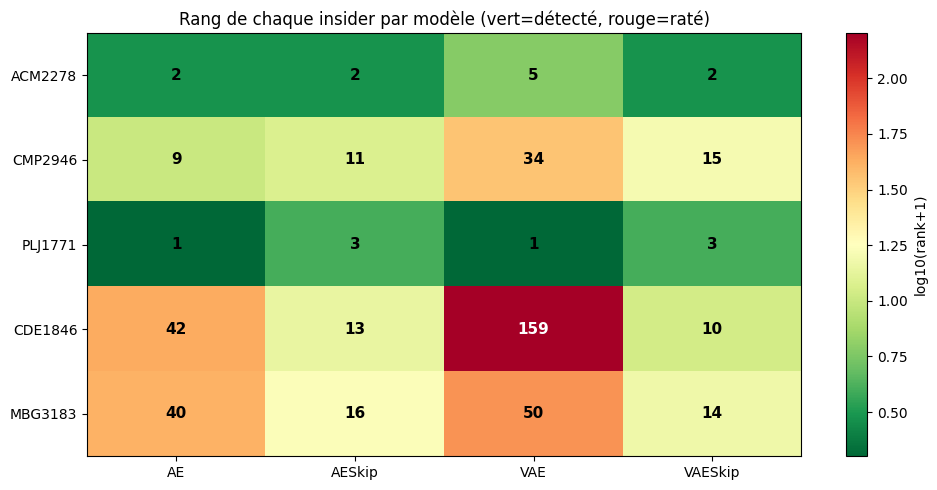

In [59]:
ranks_table = pd.DataFrame(index=INSIDERS)
for name in all_scores:
    ranks_table[name] = [results_individual[name]['ranks'].get(ins, np.nan) for ins in INSIDERS]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(np.log10(ranks_table.values + 1), cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(ranks_table.columns)))
ax.set_xticklabels(ranks_table.columns)
ax.set_yticks(range(len(ranks_table.index)))
ax.set_yticklabels(ranks_table.index)
for i in range(ranks_table.shape[0]):
    for j in range(ranks_table.shape[1]):
        v = int(ranks_table.values[i, j])
        ax.text(j, i, str(v), ha='center', va='center',
                color='white' if v > 100 else 'black', fontsize=11, fontweight='bold')
ax.set_title('Rang de chaque insider par modèle (vert=détecté, rouge=raté)', fontsize=12)
plt.colorbar(im, ax=ax, label='log10(rank+1)')
plt.tight_layout()
plt.show()

In [60]:

scores_minmax = {name: minmax(s) for name, s in all_scores.items()}
scores_zscore = {name: zscore(s) for name, s in all_scores.items()}
scores_ranks  = {name: to_ranks(s) for name, s in all_scores.items()}

results_ensembles = {}

print('='*60)
print('ENSEMBLES — 4 modèles (toutes stratégies)')
print('='*60)

# Moyenne pondérée min-max (uniforme)
ens = sum(scores_minmax.values()) / 4
results_ensembles['minmax_avg'] = eval_score(ens, 'Min-max moyenne uniforme')

# Moyenne z-score 
ens = sum(scores_zscore.values()) / 4
results_ensembles['zscore_avg'] = eval_score(ens, 'Z-score moyenne uniforme')

# MAX min-max 
ens = np.maximum.reduce(list(scores_minmax.values()))
results_ensembles['minmax_max'] = eval_score(ens, 'MAX (min-max)')

# Reciprocal Rank Fusion (k=60) 
k_rrf = 60
ens = sum(1.0 / (k_rrf + r) for r in scores_ranks.values())
results_ensembles['rrf'] = eval_score(ens, f'RRF (k={k_rrf})')

# Min-rank 
ens = -np.minimum.reduce(list(scores_ranks.values()))   
results_ensembles['min_rank'] = eval_score(ens, 'Min-rank')

# Rank averaging
ens = -sum(scores_ranks.values()) / 4
results_ensembles['rank_avg'] = eval_score(ens, 'Rank averaging')

ENSEMBLES — 4 modèles (toutes stratégies)

--- Min-max moyenne uniforme ---
   user  rank
PLJ1771     2
ACM2278     3
CMP2946    10
MBG3183    16
CDE1846    24
  Top-5: 2/5  |  Top-10: 3/5  |  Top-20: 4/5  |  mean rank: 11

--- Z-score moyenne uniforme ---
   user  rank
PLJ1771     2
ACM2278     3
CMP2946    10
MBG3183    13
CDE1846    17
  Top-5: 2/5  |  Top-10: 3/5  |  Top-20: 5/5  |  mean rank: 9

--- MAX (min-max) ---
   user  rank
PLJ1771     1
ACM2278     5
CMP2946    35
MBG3183    51
CDE1846   162
  Top-5: 2/5  |  Top-10: 2/5  |  Top-20: 2/5  |  mean rank: 51

--- RRF (k=60) ---
   user  rank
PLJ1771     2
ACM2278     3
CMP2946     8
MBG3183    14
CDE1846    16
  Top-5: 2/5  |  Top-10: 3/5  |  Top-20: 5/5  |  mean rank: 9

--- Min-rank ---
   user  rank
PLJ1771     2
ACM2278     4
CMP2946    14
CDE1846    19
MBG3183    28
  Top-5: 2/5  |  Top-10: 2/5  |  Top-20: 4/5  |  mean rank: 13

--- Rank averaging ---
   user  rank
PLJ1771     2
ACM2278     3
CMP2946     8
MBG3183    13
CD

In [61]:
print("Sweep k pour le RRF (4 modeles MSE) :")
print(f"{'k':>6} | {'top5':>5} | {'top10':>5} | {'top20':>5} | {'mean_rank':>10}")
print('-' * 45)

best_rrf_k, best_rrf_mr, best_rrf_ens = 60, float('inf'), None
for k_rrf in [5, 10, 20, 30, 60, 100, 200]:
    ens = sum(1.0 / (k_rrf + r) for r in scores_ranks.values())
    res = eval_score(ens, '', verbose=False)
    print(f"{k_rrf:>6} | {res['top5']:>5} | {res['top10']:>5} | {res['top20']:>5} | {res['mean_rank']:>10.1f}")
    if res['mean_rank'] < best_rrf_mr:
        best_rrf_mr, best_rrf_k, best_rrf_ens = res['mean_rank'], k_rrf, ens

print(f"\n-> Meilleur k : {best_rrf_k} (mean rank = {best_rrf_mr:.1f})")
if best_rrf_k != 60:
    print(f"-> Ajout de RRF k={best_rrf_k} aux strategies d'ensemble")
    results_ensembles[f'rrf_k{best_rrf_k}'] = eval_score(best_rrf_ens, f'RRF (k={best_rrf_k} optimal)')

Sweep k pour le RRF (4 modeles MSE) :
     k |  top5 | top10 | top20 |  mean_rank
---------------------------------------------
     5 |     2 |     3 |     5 |       10.0
    10 |     2 |     3 |     5 |        9.4
    20 |     2 |     3 |     5 |        8.2
    30 |     2 |     3 |     5 |        8.4
    60 |     2 |     3 |     5 |        8.6
   100 |     2 |     3 |     5 |        8.2
   200 |     2 |     3 |     5 |        8.6

-> Meilleur k : 20 (mean rank = 8.2)
-> Ajout de RRF k=20 aux strategies d'ensemble

--- RRF (k=20 optimal) ---
   user  rank
PLJ1771     1
ACM2278     3
CMP2946     9
MBG3183    13
CDE1846    15
  Top-5: 2/5  |  Top-10: 3/5  |  Top-20: 5/5  |  mean rank: 8


In [62]:
mean_ranks = {name: results_individual[name]['mean_rank'] for name in all_scores}

print('Mean rank par modèle (plus petit = mieux) :')
for name, mr in sorted(mean_ranks.items(), key=lambda x: x[1]):
    print(f'  {name:10s} : {mr:.0f}')

# On garde les modèles dont mean_rank ≤ 1.5 × meilleur mean rank
best_mr = min(mean_ranks.values())
threshold = 1.5 * best_mr
selected = [name for name, mr in mean_ranks.items() if mr <= threshold]
print(f'\nSeuil : mean_rank ≤ {threshold:.0f}')
print(f'Modèles sélectionnés : {selected}')
print(f'Modèles écartés : {[n for n in all_scores if n not in selected]}')

Mean rank par modèle (plus petit = mieux) :
  VAESkip    : 9
  AESkip     : 9
  AE         : 19
  VAE        : 50

Seuil : mean_rank ≤ 13
Modèles sélectionnés : ['AESkip', 'VAESkip']
Modèles écartés : ['AE', 'VAE']


In [40]:
print('='*60)
print(f'ENSEMBLES — Modèles sélectionnés : {selected}')
print('='*60)

results_selected = {}


selected_minmax = [scores_minmax[n] for n in selected]
selected_zscore = [scores_zscore[n] for n in selected]
selected_ranks  = [scores_ranks[n]  for n in selected]

ens = sum(selected_minmax) / len(selected_minmax)
results_selected['minmax_avg'] = eval_score(ens, f'Sélection {selected} | Min-max moyenne')

ens = sum(selected_zscore) / len(selected_zscore)
results_selected['zscore_avg'] = eval_score(ens, f'Sélection {selected} | Z-score moyenne')

ens = np.maximum.reduce(selected_minmax)
results_selected['minmax_max'] = eval_score(ens, f'Sélection {selected} | MAX min-max')

ens = sum(1.0 / (60 + r) for r in selected_ranks)
results_selected['rrf'] = eval_score(ens, f'Sélection {selected} | RRF (k=60)')

ENSEMBLES — Modèles sélectionnés : ['AE', 'VAESkip']

--- Sélection ['AE', 'VAESkip'] | Min-max moyenne ---
   user  rank
ACM2278     1
MBG3183     2
PLJ1771     3
CDE1846    17
CMP2946    21
  Top-5: 3/5  |  Top-10: 3/5  |  Top-20: 4/5  |  mean rank: 9

--- Sélection ['AE', 'VAESkip'] | Z-score moyenne ---
   user  rank
ACM2278     1
MBG3183     2
PLJ1771     3
CDE1846    16
CMP2946    22
  Top-5: 3/5  |  Top-10: 3/5  |  Top-20: 4/5  |  mean rank: 9

--- Sélection ['AE', 'VAESkip'] | MAX min-max ---
   user  rank
ACM2278     1
PLJ1771     4
MBG3183     6
CMP2946    15
CDE1846    30
  Top-5: 2/5  |  Top-10: 3/5  |  Top-20: 4/5  |  mean rank: 11

--- Sélection ['AE', 'VAESkip'] | RRF (k=60) ---
   user  rank
ACM2278     1
MBG3183     2
PLJ1771     4
CDE1846    17
CMP2946    22
  Top-5: 3/5  |  Top-10: 3/5  |  Top-20: 4/5  |  mean rank: 9


In [63]:
def grid_search_weights(scores_list, train_insiders, w_grid=21):
    """
    Cherche les poids (sommant à 1) qui minimisent le mean rank des train_insiders.
    Pour 2 modèles : 1D. Pour 3 modèles : 2D. Pour 4 modèles : 3D (lent mais OK pour 21^3).
    """
    n = len(scores_list)
    best = (float('inf'), None)
    
    if n == 2:
        for w0 in np.linspace(0, 1, w_grid):
            ws = [w0, 1 - w0]
            ens = sum(w * s for w, s in zip(ws, scores_list))
            df_s = pd.DataFrame({'user': users, 'score': ens}).sort_values('score', ascending=False)
            df_s['rank'] = range(1, len(df_s) + 1)
            ranks = df_s[df_s['user'].isin(train_insiders)]['rank']
            mr = ranks.mean()
            if mr < best[0]:
                best = (mr, ws)
    
    elif n == 3:
        for w0 in np.linspace(0, 1, w_grid):
            for w1 in np.linspace(0, 1 - w0, w_grid):
                w2 = 1 - w0 - w1
                if w2 < 0: continue
                ws = [w0, w1, w2]
                ens = sum(w * s for w, s in zip(ws, scores_list))
                df_s = pd.DataFrame({'user': users, 'score': ens}).sort_values('score', ascending=False)
                df_s['rank'] = range(1, len(df_s) + 1)
                ranks = df_s[df_s['user'].isin(train_insiders)]['rank']
                mr = ranks.mean()
                if mr < best[0]:
                    best = (mr, ws)
    
    elif n == 4:
        for w0 in np.linspace(0, 1, w_grid):
            for w1 in np.linspace(0, 1 - w0, w_grid):
                for w2 in np.linspace(0, 1 - w0 - w1, w_grid):
                    w3 = 1 - w0 - w1 - w2
                    if w3 < 0: continue
                    ws = [w0, w1, w2, w3]
                    ens = sum(w * s for w, s in zip(ws, scores_list))
                    df_s = pd.DataFrame({'user': users, 'score': ens}).sort_values('score', ascending=False)
                    df_s['rank'] = range(1, len(df_s) + 1)
                    ranks = df_s[df_s['user'].isin(train_insiders)]['rank']
                    mr = ranks.mean()
                    if mr < best[0]:
                        best = (mr, ws)
    
    return best[1]   

In [64]:
def loio_evaluation(scores_dict, label, w_grid=11):
    """
    Leave-One-Insider-Out: pour chaque insider tenu de côté, on choisit les poids
    sur les 4 autres et on évalue sur celui mis de côté.
    Retourne la liste des rangs LOIO et leur moyenne.
    """
    names = list(scores_dict.keys())
    scores_list = [minmax(scores_dict[n]) for n in names]
    
    held_out_ranks = {}
    for held_out in INSIDERS:
        train_insiders = [i for i in INSIDERS if i != held_out]
        weights = grid_search_weights(scores_list, train_insiders, w_grid=w_grid)
        
        ens = sum(w * s for w, s in zip(weights, scores_list))
        df_s = pd.DataFrame({'user': users, 'score': ens}).sort_values('score', ascending=False).reset_index(drop=True)
        df_s['rank'] = range(1, len(df_s) + 1)
        rank_held = df_s[df_s['user'] == held_out]['rank'].iloc[0]
        held_out_ranks[held_out] = (rank_held, weights)
    
    print(f'\n--- LOIO sur {label} ({names}) ---')
    for ins, (r, w) in held_out_ranks.items():
        ws = ', '.join(f'{wi:.2f}' for wi in w)
        print(f'  {ins} held out → rank {r:>4d} | weights tuned on others: [{ws}]')
    
    ranks_only = [r for r, _ in held_out_ranks.values()]
    for K in (5, 10, 20):
        hits = sum(1 for r in ranks_only if r <= K)
        print(f'  Top-{K} (LOIO honnête) : {hits}/5', end='  ')
    print(f'\n  Mean LOIO rank : {np.mean(ranks_only):.0f}')
    return held_out_ranks



print('='*60)
print('LEAVE-ONE-INSIDER-OUT — évaluation honnête')
print('='*60)

loio_2 = loio_evaluation({n: all_scores[n] for n in ['AE', 'AESkip']}, '2 modèles (AE+AESkip)')
loio_4 = loio_evaluation(all_scores, '4 modèles')
loio_sel = loio_evaluation({n: all_scores[n] for n in selected}, f'modèles sélectionnés')

LEAVE-ONE-INSIDER-OUT — évaluation honnête

--- LOIO sur 2 modèles (AE+AESkip) (['AE', 'AESkip']) ---
  ACM2278 held out → rank    3 | weights tuned on others: [0.50, 0.50]
  CMP2946 held out → rank    9 | weights tuned on others: [0.50, 0.50]
  PLJ1771 held out → rank    2 | weights tuned on others: [0.50, 0.50]
  CDE1846 held out → rank   12 | weights tuned on others: [0.50, 0.50]
  MBG3183 held out → rank   13 | weights tuned on others: [0.50, 0.50]
  Top-5 (LOIO honnête) : 2/5    Top-10 (LOIO honnête) : 3/5    Top-20 (LOIO honnête) : 5/5  
  Mean LOIO rank : 8

--- LOIO sur 4 modèles (['AE', 'AESkip', 'VAE', 'VAESkip']) ---
  ACM2278 held out → rank    3 | weights tuned on others: [0.50, 0.00, 0.00, 0.50]
  CMP2946 held out → rank   15 | weights tuned on others: [0.00, 0.00, 0.00, 1.00]
  PLJ1771 held out → rank    2 | weights tuned on others: [0.50, 0.00, 0.00, 0.50]
  CDE1846 held out → rank   16 | weights tuned on others: [0.50, 0.00, 0.05, 0.45]
  MBG3183 held out → rank   13 |

In [66]:
rows = []

for name, r in results_individual.items():
    rows.append({
        'method': f'{name} (seul)',
        'top5': r['top5'], 'top10': r['top10'], 'top20': r['top20'],
        'mean_rank': r['mean_rank']
    })


for strategy, r in results_ensembles.items():
    rows.append({
        'method': f'4 mod | {strategy}',
        'top5': r['top5'], 'top10': r['top10'], 'top20': r['top20'],
        'mean_rank': r['mean_rank']
    })

for strategy, r in results_selected.items():
    rows.append({
        'method': f'sel({"+".join(selected)}) | {strategy}',
        'top5': r['top5'], 'top10': r['top10'], 'top20': r['top20'],
        'mean_rank': r['mean_rank']
    })

df_recap = pd.DataFrame(rows).sort_values(['top20', 'top10', 'top5', 'mean_rank'],
                                          ascending=[False, False, False, True]).reset_index(drop=True)

print('='*60)
print('\nRÉCAP COMPLET (trié par top20 puis mean rank)')
print('='*60)

print(df_recap.to_string(index=False))


RÉCAP COMPLET (trié par top20 puis mean rank)
                          method  top5  top10  top20  mean_rank
                 4 mod | rrf_k20     2      3      5        8.2
                     4 mod | rrf     2      3      5        8.6
                  VAESkip (seul)     2      3      5        8.8
              4 mod | zscore_avg     2      3      5        9.0
                   AESkip (seul)     2      2      5        9.0
sel(AESkip+VAESkip) | minmax_avg     3      3      4        8.8
sel(AESkip+VAESkip) | zscore_avg     3      3      4        8.8
       sel(AESkip+VAESkip) | rrf     3      3      4        9.2
                4 mod | rank_avg     2      3      4       10.0
              4 mod | minmax_avg     2      3      4       11.0
sel(AESkip+VAESkip) | minmax_max     2      3      4       11.2
                4 mod | min_rank     2      2      4       13.4
                       AE (seul)     2      3      3       18.8
                      VAE (seul)     2      2      2     

Meilleur ensemble : rrf_k20
  top5=2  top10=3  top20=5  mean_rank=8


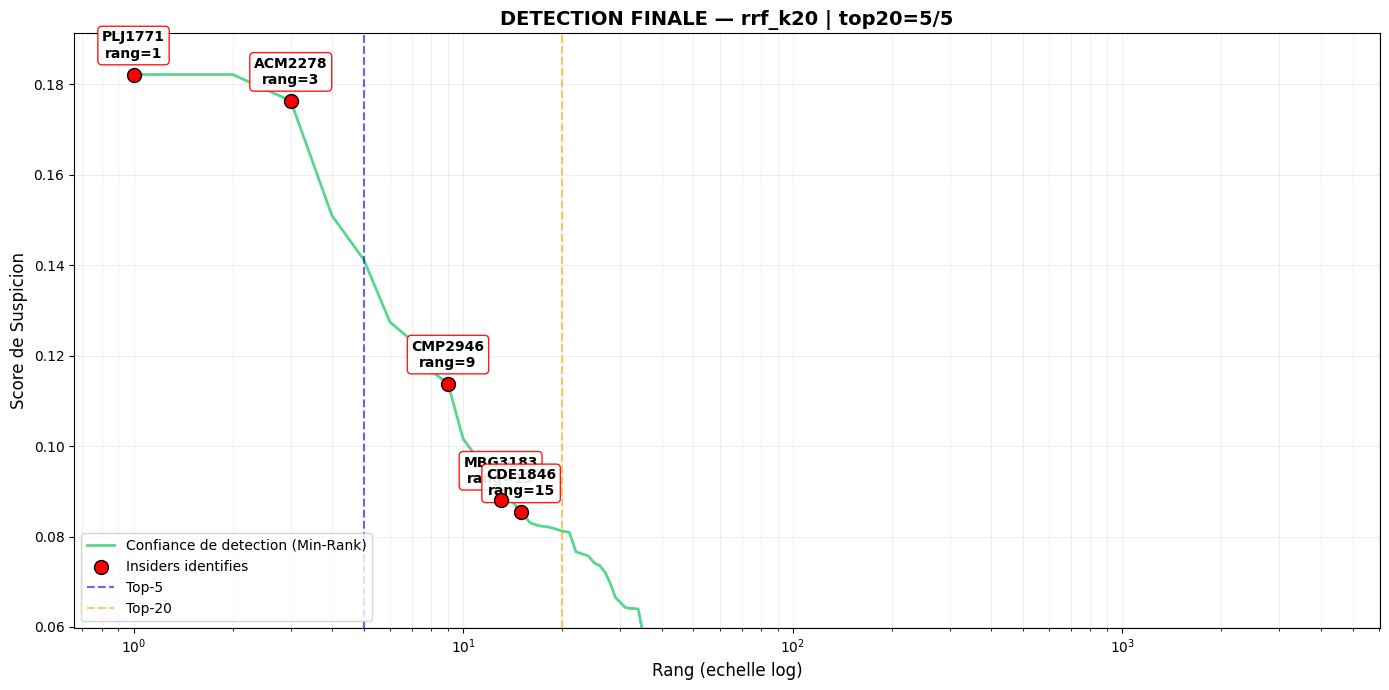


Rangs finaux des 5 insiders :
- PLJ1771: rang 1, score=0.182195
- ACM2278: rang 3, score=0.176364
- CMP2946: rang 9, score=0.113831
- MBG3183: rang 13, score=0.088142
- CDE1846: rang 15, score=0.085352


In [67]:
total_users = len(users)

all_results = {**results_ensembles}
if 'results_selected' in dir():
    all_results.update({f'sel|{k}': v for k, v in results_selected.items()})

best_key = max(all_results, key=lambda k: (
    all_results[k]['top20'],
    all_results[k]['top10'],
    all_results[k]['top5'],
    -all_results[k]['mean_rank']
))
print(f"Meilleur ensemble : {best_key}")
print(f"  top5={all_results[best_key]['top5']}  top10={all_results[best_key]['top10']}  top20={all_results[best_key]['top20']}  mean_rank={all_results[best_key]['mean_rank']:.0f}")


_sm = {n: minmax(s) for n, s in all_scores.items()}
_sr = {n: to_ranks(s) for n, s in all_scores.items()}
_score_lookup = {
    'minmax_avg':  sum(_sm.values()) / 4,
    'zscore_avg':  sum(zscore(s) for s in all_scores.values()) / 4,
    'minmax_max':  np.maximum.reduce(list(_sm.values())),
    'rrf':         sum(1.0/(60+r) for r in _sr.values()),
    'rrf_k60':     sum(1.0/(60+r) for r in _sr.values()),
    'min_rank':    -np.minimum.reduce(list(_sr.values())),
    'rank_avg':    -sum(_sr.values())/4,
}

if best_rrf_k != 60:
    _score_lookup[f'rrf_k{best_rrf_k}'] = sum(1.0/(best_rrf_k+r) for r in _sr.values())


_fallback = -np.minimum.reduce(list(_sr.values()))
best_ensemble_scores = _score_lookup.get(best_key, _fallback)


df_plot = pd.DataFrame({'user': users, 'score': best_ensemble_scores})
df_plot = df_plot.sort_values('score', ascending=False).reset_index(drop=True)
df_plot['rank'] = range(1, len(df_plot) + 1)
df_plot['is_insider'] = df_plot['user'].isin(INSIDERS)

plt.figure(figsize=(14, 7))
plt.plot(df_plot['rank'], df_plot['score'], color='#2ecc71', alpha=0.8,
         linewidth=2, label='Confiance de detection (Min-Rank)')

ins_plot = df_plot[df_plot['is_insider']]
plt.scatter(ins_plot['rank'], ins_plot['score'], color='red', s=100, zorder=5,
            edgecolors='black', label='Insiders identifies')

for _, row in ins_plot.iterrows():
    plt.annotate(f"{row['user']}\nrang={row['rank']}",
                 (row['rank'], row['score']),
                 fontsize=10, fontweight='bold', ha='center', va='bottom',
                 xytext=(0, 10), textcoords='offset points',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='red'))


min_insider_score = ins_plot['score'].min()
plt.ylim(min_insider_score - abs(min_insider_score)*0.3,
         df_plot['score'].max() * 1.05)
plt.xscale('log')

plt.xlabel('Rang (echelle log)', fontsize=12)
plt.ylabel('Score de Suspicion', fontsize=12)
plt.title(f'DETECTION FINALE — {best_key} | top20={all_results[best_key]["top20"]}/5', fontsize=14, fontweight='bold')

plt.axvline(5, color='blue', linestyle='--', alpha=0.6, label='Top-5')
plt.axvline(20, color='orange', linestyle='--', alpha=0.6, label='Top-20')
plt.legend(loc='lower left')
plt.grid(which='both', alpha=0.2)
plt.tight_layout()
plt.show()

print('\nRangs finaux des 5 insiders :')
for _, row in ins_plot.sort_values('rank').head(5).iterrows():
    print(f"- {row['user']}: rang {int(row['rank'])}, score={row['score']:.6f}")